# Looming Analysis Notebook

This notebook provides tools for loading `.braidz` files and analyzing the angular velocity response of flies to looming stimuli.

In [1]:
import zipfile
import io
import gzip
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from typing import List, Optional
from scipy.signal import savgol_filter
from scipy.stats import circmean
import glob
from pynumdiff.smooth_finite_difference import butterdiff

%matplotlib inline

/home/nfc/src/looming_analysis/.venv/lib/python3.14/site-packages/pynumdiff/__init__.py:9: UserWarning: tvrdiff, robustdiff, and lineardiff not available due to lack of convex solver. To use those, install CVXPY.
  warn("tvrdiff, robustdiff, and lineardiff not available due to lack of convex solver. To use those, install CVXPY.")


## Helper Functions

We'll define functions to load data from `.braidz` zip archives and process trajectories.

In [2]:
def load_braidz(file_path: str):
    """
    Load kalman estimates and stimulus data from a .braidz file.
    """
    with zipfile.ZipFile(file_path, 'r') as z:
        # Load kalman_estimates.csv.gz
        with z.open('kalman_estimates.csv.gz') as f:
            with gzip.open(f) as gz:
                df_kalman = pl.read_csv(gz)
        
        # Load stim.csv or visual_stimuli.csv if it exists
        df_stim = None
        if 'stim.csv' in z.namelist():
            with z.open('stim.csv') as f:
                df_stim = pl.read_csv(f)
        elif 'visual_stimuli.csv' in z.namelist():
            with z.open('visual_stimuli.csv') as f:
                df_stim = pl.read_csv(f)
                
    return df_kalman, df_stim

def calculate_angular_velocity(xvel: np.ndarray, yvel: np.ndarray, dt: float = 0.01, params: list = [1, 0.1]) -> np.ndarray:
    """
    Calculate angular velocity from velocity components.
    """
    theta = np.arctan2(yvel, xvel)
    theta_unwrap = np.unwrap(theta)
    # angular_velocity = np.gradient(theta_unwrap, dt)
    theta_unwrap, angular_velocity = butterdiff(theta_unwrap, dt=0.01, params=params)
    return angular_velocity

def extract_responses(df_kalman: pl.DataFrame, df_stim: pl.DataFrame, pre_frames: int = -50, post_frames: int = 100, k: int = 5):
    """
    Extract response trajectories for each stimulus.
    """

    if pre_frames > 0 or post_frames <= 0:
        raise ValueError("pre_frames should be negative and post_frames should be positive.")
    
    responses = []
    dt = 0.01  # 100Hz
    
    # To make it efficient, we'll group kalman by obj_id
    kalman_grouped = df_kalman.partition_by("obj_id", as_dict=True)
    
    for row in df_stim.iter_rows(named=True):
        obj_id = row['obj_id']
        stim_frame = row['frame']
        
        obj_key = (obj_id,)
        if obj_key in kalman_grouped:
            df_obj = kalman_grouped[obj_key]
            
            # Create a target frame range
            target_frames = pl.DataFrame({"frame": np.arange(stim_frame + pre_frames, stim_frame + post_frames, dtype=np.int64)})
            
            # Join with object data to see what we have
            df_res = target_frames.join(df_obj, on="frame", how="left")
            
            # Check how many frames are missing
            missing_count = df_res["xvel"].null_count()
            
            if missing_count <= k:
                # Pad missing values (pre, post, or middle) using forward and backward fill
                df_res = df_res.fill_null(strategy="forward").fill_null(strategy="backward")
                
                # Calculate angular velocity
                xvel = df_res['xvel'].to_numpy()
                yvel = df_res['yvel'].to_numpy()
                
                # Calculate heading
                headings = np.arctan2(yvel, xvel)
                
                # Heading before: average during pre_frames
                stim_idx = abs(pre_frames)
                heading_before = circmean(headings[stim_idx-10:stim_idx], low=-np.pi, high=np.pi)
                
                # Heading after: average during the period after expansion ends
                expansion_duration_ms = row.get('expansion_duration_ms', 500)
                expansion_frames = int(expansion_duration_ms / 10)
                end_expansion_idx = stim_idx + expansion_frames
                
                if end_expansion_idx < len(headings):
                    heading_after = circmean(headings[end_expansion_idx:end_expansion_idx+10], low=-np.pi, high=np.pi)
                else:
                    heading_after = headings[-1]
                
                # Heading change in degrees
                heading_change = np.rad2deg(np.arctan2(np.sin(heading_after - heading_before), np.cos(heading_after - heading_before)))
                
                ang_vel = calculate_angular_velocity(xvel, yvel, dt, params=[2, 0.2])
                
                # Store response metadata
                response_data = {
                    'ang_vel': ang_vel,
                    'heading_change': heading_change,
                    'time': (df_res['frame'].to_numpy() - stim_frame) * dt,
                    **{key: val for key, val in row.items() if key not in ['frame', 'timestamp', 'obj_id']}
                }
                responses.append(response_data)
                
    return responses

def angular_velocity_from_velocity(
    xvel: np.ndarray,
    yvel: np.ndarray,
    dt: float,
    min_speed: float = 0.1,
    order: int = 2,
    cutoff: float = 0.2,
) -> np.ndarray:
    """Compute angular velocity directly from cartesian velocity components.

    Avoids arctan2 + unwrapping entirely. Numerically stable except near
    zero speed, where heading is undefined anyway.

    Args:
        xvel: x-component of velocity
        yvel: y-component of velocity
        dt: timestep
        min_speed: speed threshold below which output is set to NaN (heading undefined)
        order: order of the Butterworth filter
        cutoff: cutoff frequency of the Butterworth filter

    Returns:
        Angular velocity in radians/s
    """
    speed_sq = xvel**2 + yvel**2

    # Differentiate velocity components
    _, dxdt = butterdiff(xvel, dt, [order, cutoff])
    _, dydt = butterdiff(yvel, dt, [order, cutoff])

    omega = (xvel * dydt - yvel * dxdt) / speed_sq
    omega[speed_sq < min_speed**2] = np.nan

    return omega

## Data Loading and Processing

Let's load all `.braidz` files in the `data` directory and extract the responses.

In [5]:
def process_all_files(file_paths: List[str], pre_frames: int = -50, post_frames: int = 100):
    """
    Process multiple .braidz files and combine the responses.
    """
    all_responses = []
    for path in file_paths:
        print(f"Processing {path}...")
        df_kalman, df_stim = load_braidz(path)
        if df_stim is not None:
            responses = extract_responses(df_kalman, df_stim, pre_frames=pre_frames, post_frames=post_frames)
            print(f"  Extracted {len(responses)} valid responses.")
            all_responses.extend(responses)
        else:
            print(f"  No stim data found in {path}.")
    return all_responses

# file_paths = glob.glob("/mnt/data/experiments/20260415_154556.braidz")
file_paths = [
    "/mnt/data/experiments/20260407_171532.braidz",
    "/mnt/data/experiments/20260410_143644.braidz"
]
all_responses = process_all_files(file_paths, pre_frames=-50, post_frames=100)
print(f"Total extracted responses: {len(all_responses)}")

Processing /mnt/data/experiments/20260407_171532.braidz...
  Extracted 78 valid responses.
Processing /mnt/data/experiments/20260410_143644.braidz...
  Extracted 73 valid responses.
Total extracted responses: 151


## Grouping and Plotting

Now we'll group the responses by stimulus parameters and plot the average angular velocity response.

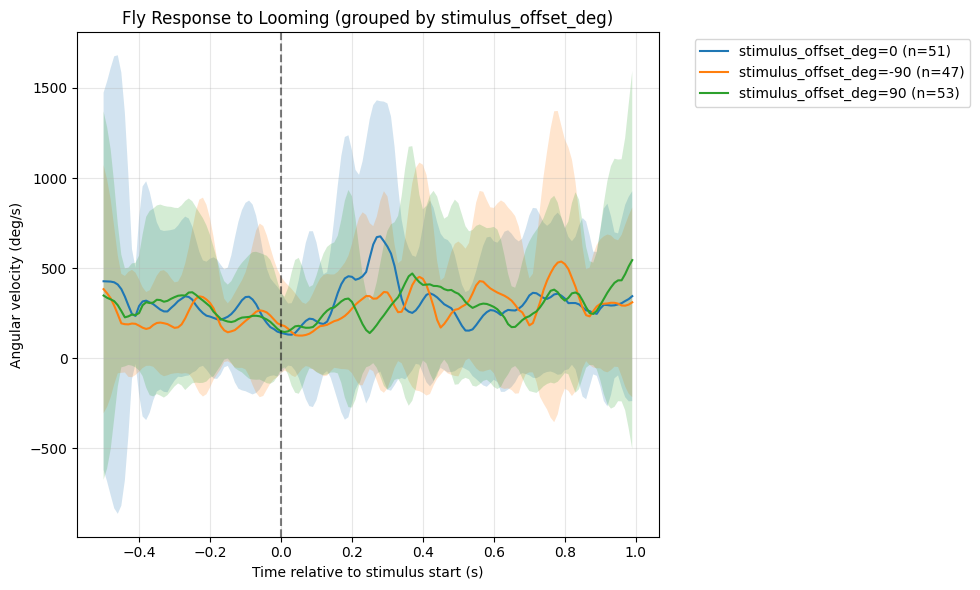

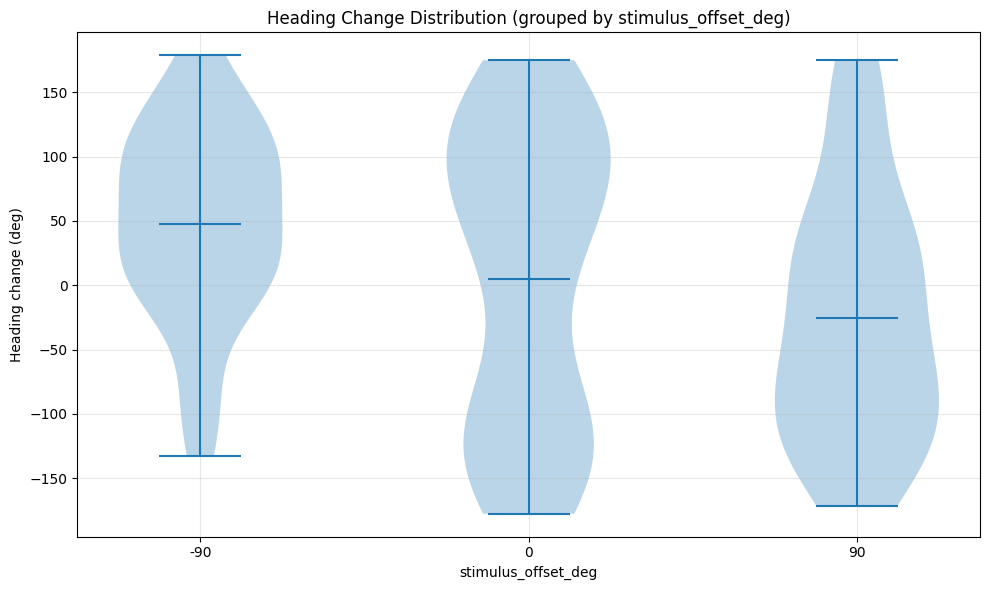

In [6]:
def plot_responses(responses, group_by: str = 'stimulus_offset_deg'):
    """
    Group responses and plot the mean angular velocity.
    """
    # Grouping
    groups = {}
    for r in responses:
        val = r.get(group_by)
        if val not in groups:
            groups[val] = []
        groups[val].append(r)
    
    plt.figure(figsize=(10, 6))
    
    for label, response_list in groups.items():
        data_list = np.stack([r['ang_vel'] for r in response_list])
        time_axis = response_list[0]['time']
            
        data_abs_deg = np.abs(np.rad2deg(np.stack(data_list)))
        mean_resp = np.nanmean(data_abs_deg, axis=0)
        sem_resp = np.nanstd(data_abs_deg, axis=0) #/ np.sqrt(np.count_nonzero(~np.isnan(padded_data), axis=0))
        
        line, = plt.plot(time_axis, mean_resp, label=f"{group_by}={label} (n={len(data_list)})")
        plt.fill_between(time_axis, mean_resp - sem_resp, mean_resp + sem_resp, alpha=0.2)
        
    plt.xlabel('Time relative to stimulus start (s)')
    plt.ylabel('Angular velocity (deg/s)')
    plt.title(f'Fly Response to Looming (grouped by {group_by})')
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_heading_changes(responses, group_by: str = 'stimulus_offset_deg'):
    """
    Plot the distribution of heading changes per group using violin plots.
    """
    groups = {}
    for r in responses:
        val = r.get(group_by)
        if val not in groups:
            groups[val] = []
        groups[val].append(r['heading_change'])
    
    labels = sorted(groups.keys())
    data = [groups[label] for label in labels]
    
    plt.figure(figsize=(10, 6))
    plt.violinplot(data, showmeans=True)
    plt.xticks(range(1, len(labels) + 1), labels)
    plt.xlabel(group_by)
    plt.ylabel('Heading change (deg)')
    plt.title(f'Heading Change Distribution (grouped by {group_by})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if all_responses:
    plot_responses(all_responses, group_by='stimulus_offset_deg')
    plot_heading_changes(all_responses, group_by='stimulus_offset_deg')